# 02 - Baseline Reproduction

This notebook reproduces and cleans the Kaggle baseline for the ECHO2022 dataset.

Main steps:
- Load local dataset paths
- Prepare training metadata
- Build train/validation split
- Create sequence loader and batch generator
- Train a TimeDistributed CNN + LSTM baseline
- Evaluate on validation set
- Save model and results

In [1]:
from pathlib import Path
import os
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
PROJECT_ROOT = Path("../").resolve()

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "echo2022"
TRAIN_CSV_PATH = DATA_ROOT / "train_data.csv"
SAMPLE_SUB_PATH = DATA_ROOT / "sample_submission.csv"

TRAIN_2CH_DIR = DATA_ROOT / "train_data" / "2CH"
TRAIN_4CH_DIR = DATA_ROOT / "train_data" / "4CH"
TEST_2CH_DIR = DATA_ROOT / "test_data" / "2CH"
TEST_4CH_DIR = DATA_ROOT / "test_data" / "4CH"

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
MODELS_DIR = RESULTS_DIR / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_4CH_DIR exists:", TRAIN_4CH_DIR.exists())
print("TEST_4CH_DIR exists:", TEST_4CH_DIR.exists())
print("TRAIN_CSV_PATH exists:", TRAIN_CSV_PATH.exists())

PROJECT_ROOT: /Users/emirarslan/Downloads/lab task/echo-project
TRAIN_4CH_DIR exists: True
TEST_4CH_DIR exists: True
TRAIN_CSV_PATH exists: True


In [4]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print("train_df shape:", train_df.shape)
print("sample_sub shape:", sample_sub.shape)

train_df.head()

train_df shape: (400, 2)
sample_sub shape: (50, 2)


,Patient_number,LV_ef
0,patient001,58.9
1,patient002,37.3
2,patient003,65.3
3,patient004,38.4
4,patient005,58.5


In [5]:
print(train_df.columns.tolist())

['Patient_number', 'LV_ef']


In [6]:
possible_id_cols = [col for col in train_df.columns if "patient" in col.lower() or "id" in col.lower()]
print("Possible ID columns:", possible_id_cols)

Possible ID columns: ['Patient_number']


In [7]:
train_df = train_df.copy()

id_col = possible_id_cols[0]

train_df["patient_str"] = train_df[id_col].astype(str).str.extract(r"(\d+)", expand=False)
train_df["patient_str"] = "patient" + train_df["patient_str"].str.zfill(3)

label_map = dict(zip(train_df["patient_str"], train_df["LV_ef"]))

print("Number of labels:", len(label_map))
list(label_map.items())[:5]

Number of labels: 400


[('patient001', 58.9),
 ('patient002', 37.3),
 ('patient003', 65.3),
 ('patient004', 38.4),
 ('patient005', 58.5)]

In [8]:
train_4ch_files = sorted([p for p in TRAIN_4CH_DIR.glob("*.npy")])
test_4ch_files = sorted([p for p in TEST_4CH_DIR.glob("*.npy")])

print("Train 4CH files:", len(train_4ch_files))
print("Test 4CH files:", len(test_4ch_files))
print("Sample train file:", train_4ch_files[0].name)

Train 4CH files: 400
Test 4CH files: 50
Sample train file: patient001_4CH_sequence.npy


In [9]:
def extract_patient_id_from_filename(filepath):
    return filepath.stem.split("_")[0]

missing_labels = []
for fp in train_4ch_files:
    patient_id = extract_patient_id_from_filename(fp)
    if patient_id not in label_map:
        missing_labels.append(fp.name)

print("Missing labels:", len(missing_labels))
missing_labels[:10]

Missing labels: 0


[]

In [10]:
train_records = []
for fp in train_4ch_files:
    patient_id = extract_patient_id_from_filename(fp)
    if patient_id in label_map:
        train_records.append({
            "filepath": fp,
            "patient_id": patient_id,
            "label": float(label_map[patient_id])
        })

train_records_df = pd.DataFrame(train_records)

print("Usable train samples:", len(train_records_df))
train_records_df.head()

Usable train samples: 400


,filepath,patient_id,label
0,/Users/emirarslan/Downloads/lab task/echo-proj...,patient001,58.9
1,/Users/emirarslan/Downloads/lab task/echo-proj...,patient002,37.3
2,/Users/emirarslan/Downloads/lab task/echo-proj...,patient003,65.3
3,/Users/emirarslan/Downloads/lab task/echo-proj...,patient004,38.4
4,/Users/emirarslan/Downloads/lab task/echo-proj...,patient005,58.5


In [11]:
train_split_df, val_split_df = train_test_split(
    train_records_df,
    test_size=0.2,
    random_state=SEED
)

train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)

print("Train split:", len(train_split_df))
print("Val split:", len(val_split_df))

Train split: 320
Val split: 80


In [12]:
IMG_SIZE = (256, 256)
N_FRAMES = 10
BATCH_SIZE = 8
EPOCHS = 10

In [13]:
def load_sequence(filepath, n_frames=N_FRAMES, img_size=IMG_SIZE):
    seq = np.load(filepath)  

    selected = seq[:n_frames]

    if selected.shape[0] < n_frames:
        pad_count = n_frames - selected.shape[0]
        pad_frame = selected[-1] if selected.shape[0] > 0 else np.zeros(seq.shape[1:], dtype=seq.dtype)
        padding = np.stack([pad_frame] * pad_count, axis=0)
        selected = np.concatenate([selected, padding], axis=0)

    resized = np.zeros((n_frames, img_size[0], img_size[1]), dtype=np.float32)

    for i, frame in enumerate(selected):
        resized[i] = cv2.resize(frame, img_size, interpolation=cv2.INTER_LINEAR)

    if resized.max() > 0:
        resized = resized / resized.max()

    resized = np.expand_dims(resized, axis=-1)

    return resized

sample_x shape: (10, 256, 256, 1)
sample_y: 38.4


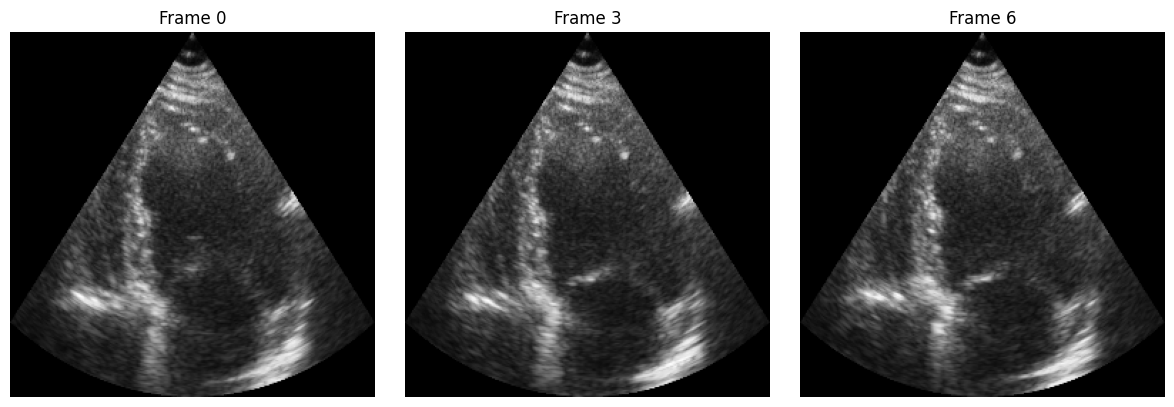

In [14]:
sample_x = load_sequence(train_split_df.loc[0, "filepath"])
sample_y = train_split_df.loc[0, "label"]

print("sample_x shape:", sample_x.shape)
print("sample_y:", sample_y)

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(sample_x[i*3, :, :, 0], cmap="gray")
    plt.title(f"Frame {i * 3}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [15]:
def data_generator(df, batch_size=BATCH_SIZE, shuffle=True):
    indices = np.arange(len(df))

    while True:
        if shuffle:
            np.random.shuffle(indices)
        
        for start_idx in range(0, len(df), batch_size):
            batch_indices = indices[start_idx:start_idx + batch_size]
            batch_df = df.iloc[batch_indices]

            X_batch = np.zeros((len(batch_df), N_FRAMES, IMG_SIZE[0], IMG_SIZE[1], 1), dtype=np.float32)
            y_batch = np.zeros((len(batch_df), 1), dtype=np.float32)

            for i, (_, row) in enumerate(batch_df.iterrows()):
                X_batch[i] = load_sequence(row["filepath"])
                y_batch[i, 0] = row["label"]
            
            yield X_batch, y_batch

In [16]:
train_gen = data_generator(train_split_df, batch_size=BATCH_SIZE, shuffle=True)
val_gen = data_generator(val_split_df, batch_size=BATCH_SIZE, shuffle=False)

X_test_batch, y_test_batch = next(train_gen)

print("X batch shape:", X_test_batch.shape)
print("y batch shape:", y_test_batch.shape)

X batch shape: (8, 10, 256, 256, 1)
y batch shape: (8, 1)


In [17]:
train_steps = int(np.ceil(len(train_split_df) / BATCH_SIZE))
val_steps = int(np.ceil(len(val_split_df) / BATCH_SIZE))

print("train_steps:", train_steps)
print("val_steps", val_steps)

train_steps: 40
val_steps 10


In [18]:
model = models.Sequential([
    layers.TimeDistributed(
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        input_shape=(N_FRAMES, IMG_SIZE[0], IMG_SIZE[1], 1)
    ),
    layers.TimeDistributed(layers.BatchNormalization()),
    layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

    layers.TimeDistributed(layers.Conv2D(64, (3, 3), activation="relu", padding="same")),
    layers.TimeDistributed(layers.BatchNormalization()),
    layers.TimeDistributed(layers.MaxPooling2D((2, 2))),

    layers.TimeDistributed(layers.Conv2D(128, (3, 3), activation="relu", padding="same")),
    layers.TimeDistributed(layers.GlobalAveragePooling2D()),

    layers.LSTM(64, return_sequences=False),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="linear")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse"), "mae"]
)

model.summary()

/Users/emirarslan/Downloads/lab task/echo-project/.venv/lib/python3.13/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 10, 256, 256,   │           320 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 256, 256,   │           128 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 128, 128,   │             0 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 128, 128,   │        18,496 │
│ (TimeDistributed)               │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 128, 128,   │           256 │
│ (TimeDistributed)               │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 10, 64, 64, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 10, 64, 64,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 10, 128)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,577 (564.75 KB)

 Trainable params: 144,385 (564.00 KB)

 Non-trainable params: 192 (768.00 B)

In [19]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / "baseline_best.keras"),
        monitor="val_loss",
        save_best_only=True
    )
]

In [20]:
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 374s 9s/step - loss: 2107.5823 - mae: 44.0554 - rmse: 45.9084 - val_loss: 1763.5647 - val_mae: 40.5436 - val_rmse: 41.9948
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 397s 10s/step - loss: 1295.2869 - mae: 33.8519 - rmse: 35.9901 - val_loss: 941.2297 - val_mae: 28.8134 - val_rmse: 30.6795
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 314s 8s/step - loss: 634.3087 - mae: 22.2964 - rmse: 25.1855 - val_loss: 412.8885 - val_mae: 17.9212 - val_rmse: 20.3197
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 303s 8s/step - loss: 300.3246 - mae: 14.4467 - rmse: 17.3299 - val_loss: 180.7304 - val_mae: 11.0796 - val_rmse: 13.4436
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 297s 7s/step - loss: 226.9502 - mae: 12.2310 - rmse: 15.0649 - val_loss: 127.6987 - val_mae: 9.0825 - val_rmse: 11.3004
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 315s 8s/step - loss: 213.7375 - mae: 11.6598 - rmse: 14.6198 - val_loss: 127.3907 - val_mae: 8.9526 - val_rmse: 11.2867
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 299s 7

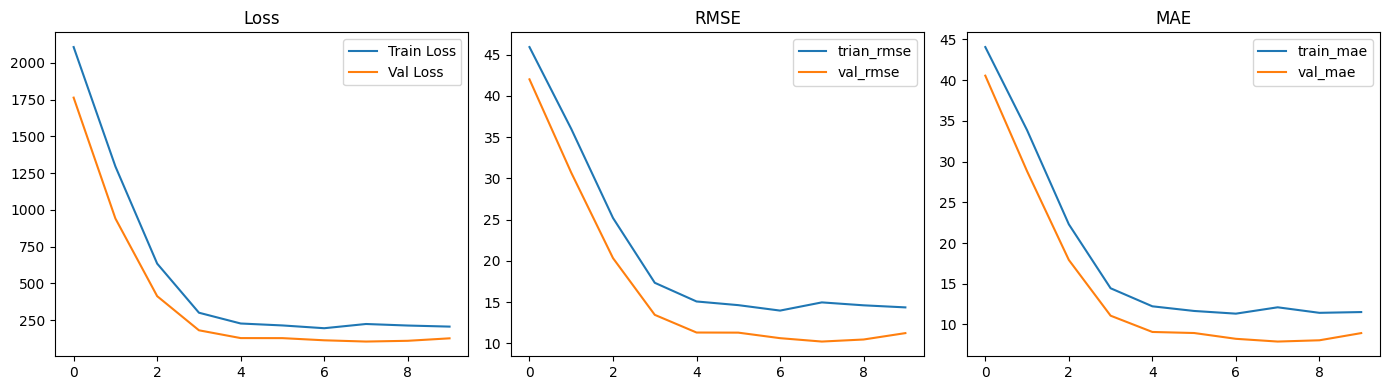

In [21]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(METRICS_DIR / "baseline_history.csv", index=False)

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(history.history["rmse"], label="trian_rmse")
plt.plot(history.history["val_rmse"], label="val_rmse")
plt.title("RMSE")
plt.legend()

plt.subplot(1,3,3)
plt.plot(history.history["mae"], label="train_mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.title("MAE")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

In [22]:
val_predictions = []
val_targets = []

for _, row in val_split_df.iterrows():
    x = load_sequence(row["filepath"])
    pred = model.predict(np.expand_dims(x, axis=0), verbose=0)[0,0]

    val_predictions.append(pred)
    val_targets.append(row["label"])

val_predictions = np.array(val_predictions)
val_targets = np.array(val_targets)

rmse = np.sqrt(mean_squared_error(val_targets, val_predictions))
mae = mean_absolute_error(val_targets, val_predictions)
r2 = r2_score(val_targets, val_predictions)

print("Validation RMSE:", rmse)
print("Validation MAE:", mae)
print("Validation R2:", r2)

Validation RMSE: 11.164773770954898
Validation MAE: 9.046946468353273
Validation R2: -0.04175969790416856


In [23]:
metrics_df = pd.DataFrame([{
    "val_rmse": rmse,
    "val_mae": mae,
    "val_r2": r2,
    "n_train": len(train_split_df),
    "n_val": len(val_split_df),
    "n_frames": N_FRAMES,
    "img_size": str(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS
}])

metrics_df.to_csv(METRICS_DIR / "baseline_validation_metrics.csv", index=False)
metrics_df

,val_rmse,val_mae,val_r2,n_train,n_val,n_frames,img_size,batch_size,epochs
0,11.164774,9.046946,-0.04176,320,80,10,"(256, 256)",8,10


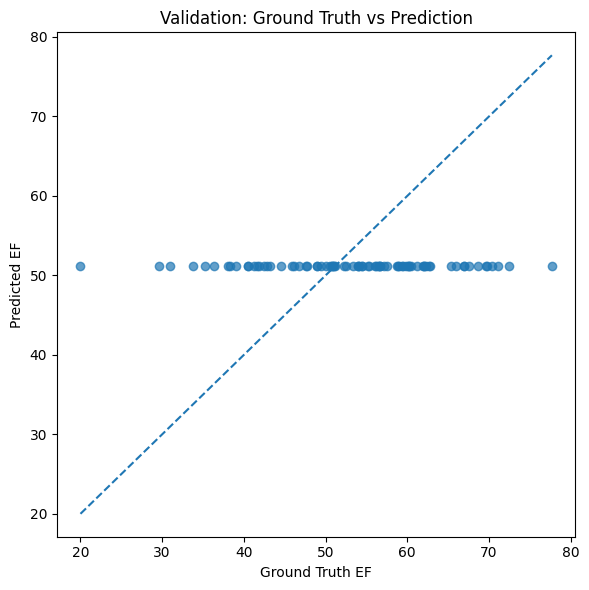

In [25]:
plt.figure(figsize=(6,6))
plt.scatter(val_targets, val_predictions, alpha=0.7)
# plt.plot([val_targets.min(), val_targets.max()],
#          [val_targets.min(), val_targets.max()],
#          linestyle="--")
plt.plot(
    [np.min(val_targets), np.max(val_targets)],
    [np.min(val_targets), np.max(val_targets)],
    linestyle="--"
)

plt.xlabel("Ground Truth EF")
plt.ylabel("Predicted EF")
plt.title("Validation: Ground Truth vs Prediction")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "val_gt_vs_pred.png", dpi=200, bbox_inches="tight")
plt.show()

In [27]:
val_results_df = val_split_df.copy()
val_results_df["prediction"] = val_predictions
val_results_df["abs_error"] = np.abs(val_results_df["label"] - val_results_df["prediction"])

best_cases = val_results_df.sort_values("abs_error").head(3)
worst_cases = val_results_df.sort_values("abs_error", ascending=False).head(3)

print("Best cases:")
display(best_cases[["patient_id", "label", "prediction", "abs_error"]])

print("Worst cases:")
display(worst_cases[["patient_id", "label", "prediction", "abs_error"]])

Best cases:


,patient_id,label,prediction,abs_error
49,patient174,51.1,51.175819,0.075819
37,patient343,51.0,51.174610,0.174610
47,patient182,50.9,51.174622,0.274622


Worst cases:


,patient_id,label,prediction,abs_error
61,patient295,20.0,51.175808,31.175808
0,patient210,77.7,51.175442,26.524558
33,patient058,29.6,51.174984,21.574984


In [28]:
test_predictions = []
for fp in test_4ch_files:
    x = load_sequence(fp)
    pred = model.predict(np.expand_dims(x, axis=0), verbose=0)[0,0]
    test_predictions.append(pred)

test_predictions = np.array(test_predictions)
print("Number of test predictions:", len(test_predictions))
print(test_predictions[:5])

Number of test predictions: 50
[51.17608  51.175552 51.17613  51.17606  51.173855]


In [29]:
sample_sub.head()

,Patient_number,LV_ef
0,patient0001,3.265477
1,patient0002,78.472759
2,patient0003,43.047281
3,patient0004,1.598960
4,patient0005,96.447658


In [31]:
submission = sample_sub.copy()
target_col = [col for col in submission.columns if col != submission.columns[0]][0]
submission[target_col] = test_predictions

submission_path = RESULTS_DIR / "baseline_submission.csv"
submission.to_csv(submission_path, index=False)

print("Saved to:", submission_path)
submission.head()

Saved to: /Users/emirarslan/Downloads/lab task/echo-project/results/baseline_submission.csv


,Patient_number,LV_ef
0,patient0001,51.176079
1,patient0002,51.175552
2,patient0003,51.176128
3,patient0004,51.176060
4,patient0005,51.173855


## Notes

- This baseline uses only 4CH sequences
- Only the first 10 frames are used
- Frames are resized to 256x256
- The task is treated as direct EF regression
- No segmentation masks are used in this baseline
- Validation split was added locally for more reliable evaluation

In [37]:
print("=" * 80)
print("TRAINING + EVALUATION CHECK")
print("=" * 80)

print("\n[1] Missing labels")
print(len(missing_labels))

print("\n[2] Sample tensor")
print("sample_x shape:", sample_x.shape)
print("sample_x min/max:", float(sample_x.min()), float(sample_x.max()))
print("sample_y:", float(sample_y))

print("\n[3] Fresh batch")
Xb, yb = next(data_generator(train_split_df, batch_size=BATCH_SIZE, shuffle=True))
print("Xb shape:", Xb.shape)
print("yb shape:", yb.shape)
print("Xb min/max:", float(Xb.min()), float(Xb.max()))

print("\n[4] Validation metrics")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

print("\n[5] History keys")
print(list(history.history.keys()))

print("\n[6] Last epoch values")
for key, value in history.history.items():
    print(key, "->", value[-1])

TRAINING + EVALUATION CHECK

[1] Missing labels
0

[2] Sample tensor
sample_x shape: (10, 256, 256, 1)
sample_x min/max: 0.0 1.0
sample_y: 38.4

[3] Fresh batch
Xb shape: (8, 10, 256, 256, 1)
yb shape: (8, 1)
Xb min/max: 0.0 1.0

[4] Validation metrics
RMSE: 11.164773770954898
MAE: 9.046946468353273
R2: -0.04175969790416856

[5] History keys
['loss', 'mae', 'rmse', 'val_loss', 'val_mae', 'val_rmse']

[6] Last epoch values
loss -> 205.8621063232422
mae -> 11.52548885345459
rmse -> 14.347895622253418
val_loss -> 126.08314514160156
val_mae -> 8.94288158416748
val_rmse -> 11.22867488861084
